## Import Libraries

In [1]:
import pandas as pd
import sys
sys.path.append('..')
from src.load_data import load_data
from src.technical_indicators import technical_analysis
from src.financial_metrics import financial_metrics
from src.plot import moving_averages
from src.plot import rsi_plot
from src.plot import cumulative
from src.plot import daily_returns
from src.plot import macd_result
from src.plot import correlation_map
%matplotlib inline

## Load and prepare the data

In [2]:
data = load_data('../data/NVDA.csv')
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)
data.head(10)

,Close,High,Low,Open,Volume
Date,,,,,
2009-01-02,0.199652,0.201027,0.184294,0.184982,497124000
2009-01-05,0.203319,0.207904,0.195984,0.197360,705736000
2009-01-06,0.210196,0.216156,0.204695,0.209279,657904000
2009-01-07,0.197589,0.205382,0.190483,0.205382,870096000
2009-01-08,0.192546,0.195067,0.180626,0.195067,1014496000
2009-01-09,0.181773,0.192546,0.181314,0.192546,761352000
2009-01-12,0.174437,0.182689,0.171916,0.181773,645532000
2009-01-13,0.175354,0.182002,0.165269,0.168478,1824424000
2009-01-14,0.167561,0.171228,0.165039,0.169165,974908000


## Checking if there is NULL Value in the Data

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3774 entries, 2009-01-02 to 2023-12-29
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   3774 non-null   float64
 1   High    3774 non-null   float64
 2   Low     3774 non-null   float64
 3   Open    3774 non-null   float64
 4   Volume  3774 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 176.9 KB


## Apply Analysis Indicators with TA-Lib

In [4]:
sma_20,ema_20,rsi,macd,macd_signal,macd_hist = technical_analysis(data['Close'])
ta_df = pd.DataFrame({"SMA_20": sma_20.index, "EMA_20":ema_20.index, "RSI":rsi.index, "MACD": macd.index, "MACD_Signal":macd_signal.index, "MACD_Hist": macd_hist.index})
ta_df.head(10)

,SMA_20,EMA_20,RSI,MACD,MACD_Signal,MACD_Hist
0,2009-01-02,2009-01-02,2009-01-02,2009-01-02,2009-01-02,2009-01-02
1,2009-01-05,2009-01-05,2009-01-05,2009-01-05,2009-01-05,2009-01-05
2,2009-01-06,2009-01-06,2009-01-06,2009-01-06,2009-01-06,2009-01-06
3,2009-01-07,2009-01-07,2009-01-07,2009-01-07,2009-01-07,2009-01-07
4,2009-01-08,2009-01-08,2009-01-08,2009-01-08,2009-01-08,2009-01-08
5,2009-01-09,2009-01-09,2009-01-09,2009-01-09,2009-01-09,2009-01-09
6,2009-01-12,2009-01-12,2009-01-12,2009-01-12,2009-01-12,2009-01-12
7,2009-01-13,2009-01-13,2009-01-13,2009-01-13,2009-01-13,2009-01-13
8,2009-01-14,2009-01-14,2009-01-14,2009-01-14,2009-01-14,2009-01-14
9,2009-01-15,2009-01-15,2009-01-15,2009-01-15,2009-01-15,2009-01-15


## Financial Metrics

In [5]:
returns,cumulative_returns, volatility = financial_metrics(data['Close'])
volatility_percent = volatility* 100
print(f"Annualized Volatility(Measure of how risky) is: {volatility_percent:.2f}%")

Annualized Volatility(Measure of how risky) is: 45.90%


## VISUALIZE DATA


### Stock Close Price and Moving Averages

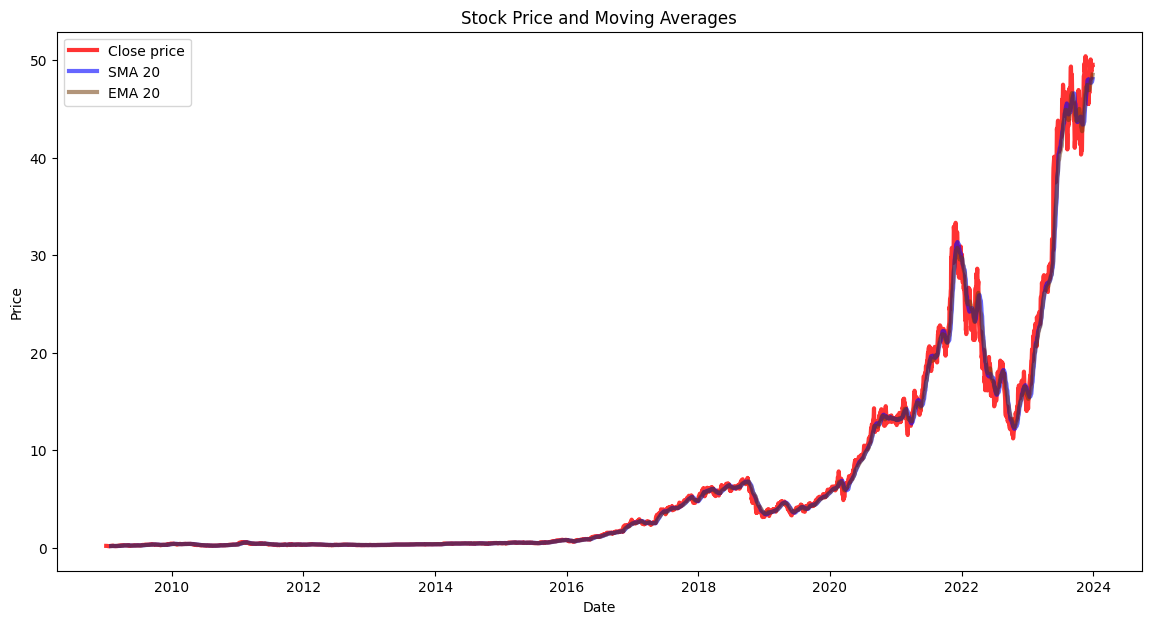

In [6]:
moving_averages(data['Close'], sma_20, ema_20)

## RSI Plot

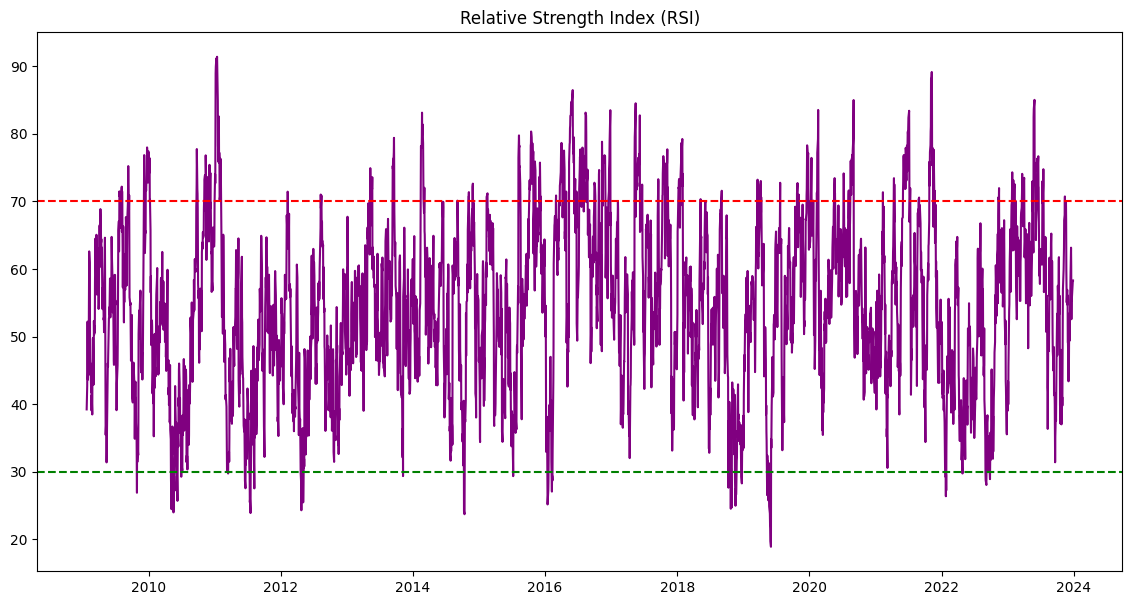

In [7]:
rsi_plot(rsi)

## Cumulative Returns

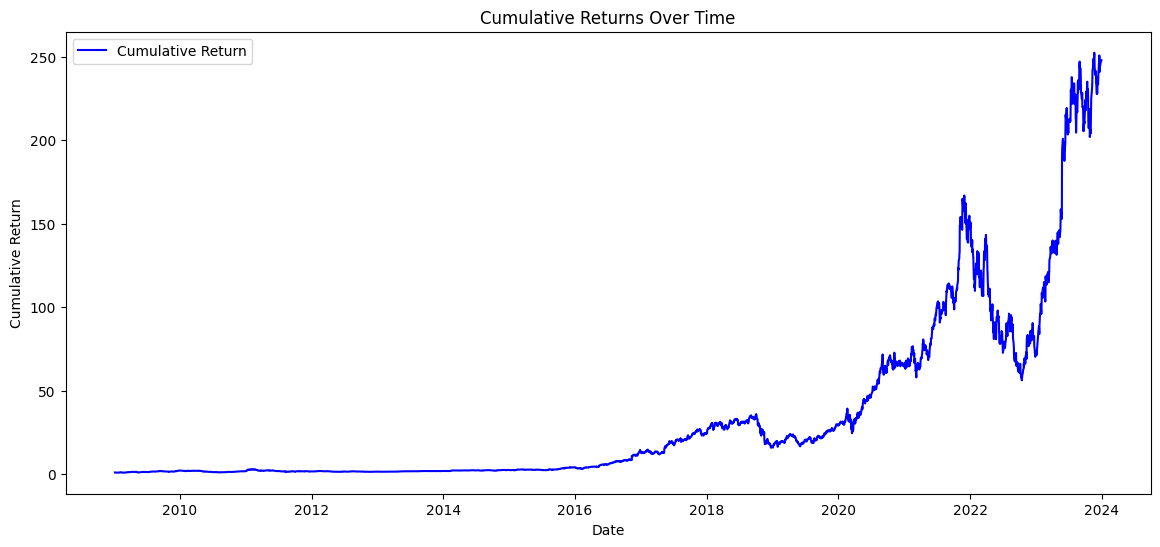

In [8]:
cumulative(cumulative_returns)

## Daily Rturns

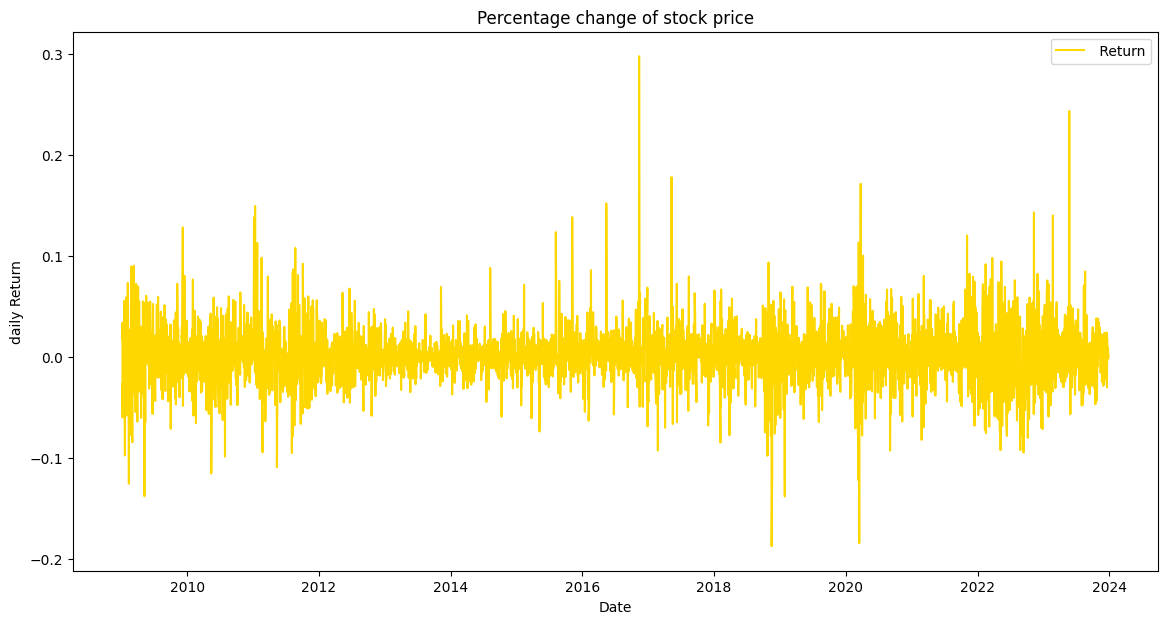

In [9]:
daily_returns(returns)

### Moving Average Convergence Divergence

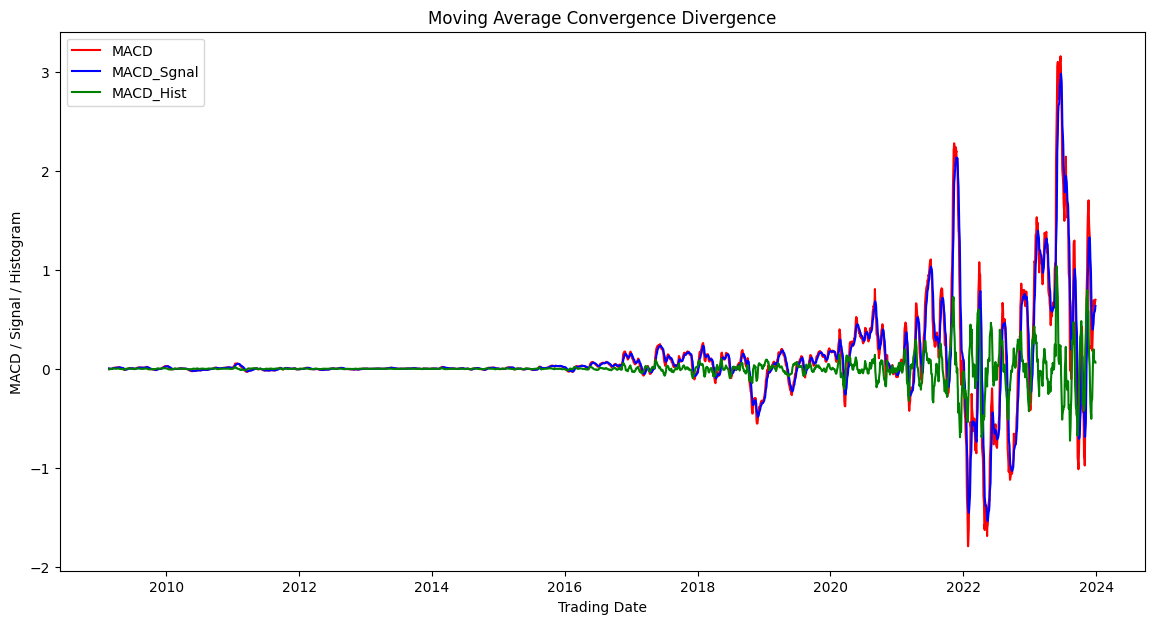

In [10]:
macd_result(macd, macd_signal, macd_hist)

### Correlation of The Data's Columns

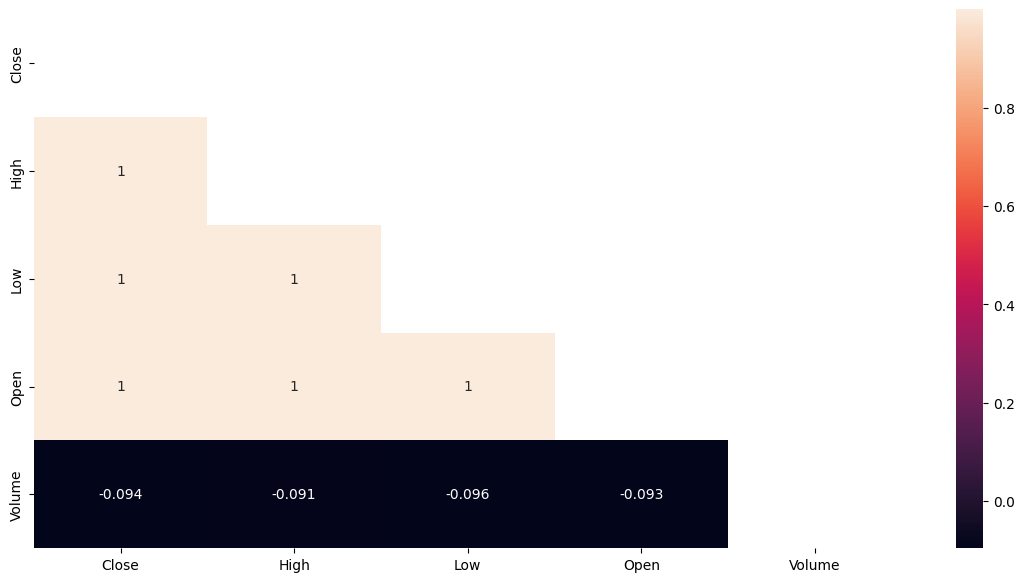

In [11]:
corr_data = data.corr()
correlation_map(corr_data)